<a href="https://colab.research.google.com/github/CY-PI/ML_Projects/blob/main/EmployeeAttrition/MVP_ML_Analytics_20261_Cyntia_English.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Name:** Cyntia P. Invernizzi  
**Date:** 03/07/2026  
**Dataset:** IBM HR Analytics Employee Attrition & Performance (dataset sintético), Kaggle (https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)  
**Problem Type:** Classification

---



# 1. Problem definition

##1.1 Problem description

Using a Human Resources dataset, I am building a machine learning classification model to predict employee attrition risk (voluntary turnover).

Currently, there is a high market demand for People Analytics professionals who can leverage data to solve workforce challenges. Designed to be used by HR analysts in partnership with corporate leadership, this model could be applied to:

1. Proactive Talent Retention: By mapping key employees and simulating flight risk, leadership can proactively intervene on a case-by-case basis, offering targeted incentives such as long-term retention packages.

2. Data-Driven HR Initiatives: By extracting feature importance, HR can design targeted initiatives such as inclusion programs or paid time off for volunteering.

## 1.2 MVP objective

This MVP aims to build and evaluate classification models for predicting employee attrition risk by comparing a baseline approach against candidate models and discussing their limitations. Additionally, it leverages model interpretability to identify which features most heavily drive the decision to leave.


## 1.3 Problem type

**Type:** Classification

**Explanation:** The Attrition target variable is "Yes" (1) or "No" (0), two discrete categories. Therefore, this is a classification problem.


## 1.4 Assumptions, hypotheses, and success criteria

**Initial Hypothesis:**
The three features below are hypothesized to be the top drivers of employee attrition:
EnvironmentSatisfaction: the lower the score, the higher the risk;
WorkLifeBalance: lower levels correlate with higher risk;
YearsSinceLastPromotion: longer periods without a promotion increase the risk.  
  

**Success Criteria:**
- Primary Metric: Recall. This metric is the most appropriate given the imbalanced target variable and our objective to minimize false negatives (even at the expense of increasing false positives). This assumption is grounded in the fact that losing talent costs the company significantly more than retaining them — up to 200% of an employee's annual salary, in addition to intangible costs (MID BY FALCONI, 2026).
- Secondary Metrics:
    - The model must maintain a solid balance between recall and precision to ensure the company does not waste resources on employees who are not actually at risk of leaving. Thus, the F1-score will serve as a key secondary metric.
    - We also need to ensure the model effectively discriminates between classes; therefore, ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) is equally important.  


- Minimum Expected Results**:
    - Recall: Around 70% (note that pushing recall higher will impact precision and, consequently, the F1-score).
    - F1-score: If candidate models tie in recall, the one with the highest F1-score will be selected.
    - ROC-AUC: Greater than or equal to 80% (≥0.80).  
  
  
**Practical Constraints**: Depending on the selected model, interpretability may be a limitation. More complex models like SVM or XGBoost do not provide direct linear coefficients to explain predictions in the same straightforward way that Logistic Regression does. Furthermore, the small dataset size (1,470 rows) may limit the models' generalization capacity.


** aligned with market practices (PEOPLEPILOT, 2025).

# 2. Environment, libraries, and reproducibility

## 2.1 Additional dependencies

Extra Packages: XGBoost and Statsmodels.

In [157]:
!pip install -q xgboost
!pip install statsmodels


## 2.2 Libraries

In [158]:
# Importing Libraries ====================
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import importlib.metadata

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

from scipy.stats import randint, uniform, loguniform, chi2_contingency, mannwhitneyu

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

print("Library versions:")
for lib in ["pandas", "numpy", "matplotlib", "scikit-learn", "xgboost", "statsmodels", "scipy"]:
  print(f"\t - {lib}: {importlib.metadata.version(lib)}")



Library versions:
	 - pandas: 2.2.2
	 - numpy: 2.0.2
	 - matplotlib: 3.10.0
	 - scikit-learn: 1.6.1
	 - xgboost: 3.3.0
	 - statsmodels: 0.14.6
	 - scipy: 1.16.3


In [159]:
# Setting up Seed
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("\nSeed:", SEED)


Seed: 42


## 2.3 Helper functions



In [160]:
# Model Evaluation & Reporting ====================================
def evaluate_classification(y_true, y_pred, proba=None):
  """Calculate basic metrics for classification."""
  results = {
      "recall": round(recall_score(y_true, y_pred), 4),
      "f1": round(f1_score(y_true, y_pred, average="binary"), 4),
  }

  # ROC AUC is best suited for evaluating binary classification models based on probability scores.
  try:
      if proba is not None and proba.shape[1] == 2:
          results["roc_auc"] = round(roc_auc_score(y_true, proba[:, 1]), 4)
      else:
          results["roc_auc"] = np.nan
  except Exception:
      results["roc_auc"] = np.nan

  return results

def show_results_table(results_dict):
  """Display results as a sortable DataFrame."""
  return pd.DataFrame(results_dict).T

def list_add(model_name_to_display, results_list, model_name, comments):
  """Returns a formatted row for the Section 11 comparison table"""
  table_format = {
    "Model": model_name_to_display,
    "Recall": results_list[model_name]["recall"],
    "F1": results_list[model_name]["f1"],
    "ROC-AUC": results_list[model_name]["roc_auc"],
    "Train Time": results_list[model_name]["train_time_s"],
    "Comments": comments
  }
  return table_format

def compute_models(model_name, model, X_train, y_train, X_test, y_test, \
                   results, is_candidate=False):
  """Train, predict and store the model and results in the dictionaries trained_models and results"""
  t0 = time.time()
  model.fit(X_train, y_train)
  train_time = time.time() - t0

  y_pred = model.predict(X_test)

  proba = model.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
  results[model_name] = evaluate_classification(y_test, y_pred, proba)

  results[model_name]["train_time_s"] = round(train_time, 3)

  # For over/underfitting analysis
  if is_candidate:
    y_pred_train = model.predict(X_train)
    results[model_name]["*recall_train"] = round(recall_score(y_train, y_pred_train), 4)

  return model


In [161]:
# Multicolinearity =================================

def calculate_vif(df_features):
  """"Calculating VIF to detect multicollinearity"""

  df_vif = df_features.copy()
  df_vif = add_constant(df_vif)

  vif = pd.DataFrame()

  vif["feature"] = df_vif.columns

  vif["VIF"] = [variance_inflation_factor(df_vif.values, df_vif.columns.get_loc(col))
                    for col in df_vif.columns]

  # Remove constant row to display only model features
  vif = vif[vif["feature"] != "const"]

  return vif.sort_values("VIF", ascending=False)

# 3. Data acquisition and selection

## 3.1 Data source

- Dataset Name: IBM HR Analytics Employee Attrition & Performance
- Source Link: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

This dataset was selected because I wanted to tackle a real-world problem mirroring the daily challenges faced by a People Analytics professional. It is publicly available on Kaggle and consists entirely of synthetic data, effectively eliminating any ethical, privacy, confidentiality, or licensing concerns.

In relation to practical constraints, the Kaggle file size is lightweight (223 KB), making it small enough to be hosted directly on GitHub without storage issues. At the same time, its 1,470 rows provide sufficient volume to effectively train and evaluate our candidate classification models.

## 3.2 Data loading


In [162]:
url = "https://raw.githubusercontent.com/CY-PI/_ML_PUCRIO/refs/heads/main/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(url)

df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3.3 Dataset overview


###3.3.1 Target description

The model's target variable is the Attrition column, which indicates whether an employee voluntarily left the company (Yes) or stayed (No).

In [163]:
TARGET = "Attrition"

###3.3.2 Data shape and types

In [164]:
print("Data shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("type"))

Data shape: (1470, 35)

Data types:


,type
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


###3.3.3 Missing values

In [165]:
print("\nMissing Values per Column:")
nulls = df.isna().sum().to_frame("missing")
count_nulls = nulls["missing"].sum()
if count_nulls == 0:
  print("No missing values found in the dataset.")
else:
  display(nulls[nulls["missing"] > 0])


Missing Values per Column:
No missing values found in the dataset.


###3.3.4 Duplicated values

In [166]:
print("Duplicates:", df.duplicated().sum())


Duplicates: 0


###3.3.5 Dataset sample

In [167]:
display(df.sample(5, random_state=SEED))

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1041,28,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,...,4,80,0,6,4,3,5,4,1,3
184,53,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,...,3,80,2,5,3,3,4,2,1,3
1222,24,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,...,3,80,1,1,2,3,1,0,0,0
67,45,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,...,3,80,1,25,2,3,1,0,0,0
220,36,No,Travel_Rarely,1396,Research & Development,5,2,Life Sciences,1,304,...,4,80,0,16,3,4,13,11,3,7


###3.3.6 Removal of non-predictive features

In [168]:
ID_COLUMNS = ["EmployeeNumber"]

# Columns with constant values
CONSTANT_COLUMNS = list(df.columns[df.nunique() == 1].tolist())

columns_to_exclude = set(ID_COLUMNS + CONSTANT_COLUMNS)

print("Features to be excluded:")
for item in sorted(columns_to_exclude):
  print("\t -", item)

Features to be excluded:
	 - EmployeeCount
	 - EmployeeNumber
	 - Over18
	 - StandardHours


## 3.4 Data dictionary

| Column | Type | Description | Included in model? | Notes |
|---|---|---|---|---|
| Age | numerical (discrete) | Employee's age | yes | N/A |
| BusinessTravel | categorical (nominal) | Employee's business travel frequency | yes | N/A |
| DailyRate | numerical (continuous) | Daily salary rate | yes | N/A |
| Department | categorical (nominal) | Employee's department | yes | N/A |
| DistanceFromHome | numerical (discrete) | Commute distance from home to work (in miles) | yes | N/A |
| Education | categorical (ordinal) | Employee's education level | yes | 1: Below College; 2: College; 3: Bachelor; 4: Master; 5: Doctor |
| EducationField | categorical (nominal) | Field of study | yes | N/A |
| EmployeeCount | numerical (constant) | Constant value with no predictive power | no | Constant columns dropped (Section 3.3.6) |
| EmployeeNumber | categorical (nominal) | Employee ID | no | ID column dropped (Section 3.3.6); although numerical, it serves merely as an identifier rather than a quantitative measure |
| EnvironmentSatisfaction | categorical (ordinal) | Satisfaction with physical and cultural work environment | yes | 1: Low; 2: Medium; 3: High; 4: Very High |
| Gender | categorical (nominal) | Employee's gender | yes | Although binary in this dataset, gender is typically classified as nominal (SURVEYLAB, 2026) |
| HourlyRate | numerical (continuous) | Hourly salary rate | yes | N/A |
| JobInvolvement | categorical (ordinal) | Level of job involvement | yes | 1: Low; 2: Medium; 3: High; 4: Very High |
| JobLevel | categorical (ordinal) | Hierarchical job level | no | Initially included, but dropped later due to multicollinearity |
| JobRole | categorical (nominal) | Employee's job role | yes | N/A |
| JobSatisfaction | categorical (ordinal) | Job satisfaction level | yes | 1: Low; 2: Medium; 3: High; 4: Very High |
| MaritalStatus | categorical (nominal) | Marital status | yes | N/A |
| MonthlyIncome | numerical (continuous) | Monthly salary amount | yes | N/A |
| MonthlyRate | numerical (continuous) | Monthly rate | yes | N/A |
| NumCompaniesWorked | numerical (discrete) | Number of companies the employee has previously worked for | yes | N/A |
| Over18 | categorical (constant) | Indicates whether the employee is over 18 | no | In this dataset, all employees are over 18; carries no predictive value |
| OverTime | categorical (binary) | Indicates whether the employee works overtime | yes | Converted from Yes/No to 1/0 |
| PercentSalaryHike | numerical (continuous) | Salary increase percentage from the last cycle | yes | N/A |
| PerformanceRating | categorical (ordinal) | Employee's performance rating | no | Initially included, but dropped later due to multicollinearity |
| RelationshipSatisfaction | categorical (ordinal) | Satisfaction with workplace interpersonal relationships | yes | 1: Low; 2: Medium; 3: High; 4: Very High |
| StandardHours | numerical (constant) | Standard working hours | no | Constant across all employees |
| StockOptionLevel | categorical (ordinal) | Company stock option level granted to the employee | yes | N/A |
| TotalWorkingYears | numerical (discrete) | Total years of professional experience | yes | N/A |
| TrainingTimesLastYear | numerical (discrete) | Number of trainings attended in the previous year | yes | N/A |
| WorkLifeBalance | categorical (ordinal) | Work-life balance level | yes | 1: Bad, 2: Good, 3: Better, 4: Best |
| YearsAtCompany | numerical (discrete) | Years spent at the current company | yes | N/A |
| YearsInCurrentRole | numerical (discrete) | Years in the current role | yes | N/A |
| YearsSinceLastPromotion | numerical (discrete) | Years since last promotion | yes | N/A |
| YearsWithCurrManager | numerical (discrete) | Years under current manager | yes | N/A |
| Attrition | categorical (binary) | Model target variable, as detailed in Section 3.3.1 | yes, TARGET | N/A |

# 4. Exploratory Data Analysis (EDA)

##4.1 Target distribution

In [169]:
print("Target distribution:")

count_table = df[TARGET].value_counts(dropna=False).to_frame("Count")
count_table["Percentage (%)"] = (df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2)

print(count_table.to_markdown(tablefmt="grid"))



Target distribution:
+-------------+---------+------------------+
| Attrition   |   Count |   Percentage (%) |
+=============+=========+==================+
| No          |    1233 |            83.88 |
+-------------+---------+------------------+
| Yes         |     237 |            16.12 |
+-------------+---------+------------------+


The target variable is observed to be imbalanced, with 84% "No" and 16% "Yes" instances. Consequently, we will need to implement specific strategies to handle this class disparity: applying stratified sampling when splitting the dataset into training and test sets to maintain the exact 84:16 class ratio across both splits, and assigning higher weights to the minority class when configuring the models.

##4.2 Feature relationship with the target

This section is designed to help us identify key variables, for which we will subsequently analyze data distributions.

###4.2.1 Relationship between categorical features and the target (excluding ordinals)

To calculate the correlation between categorical variables and the binary target, we will use Cramér's V, derived from the Chi-Square test (chi2_contingency). This metric is well-suited for measuring the strength of association between two categorical variables, yielding a value between 0 and 1.

Because Cramér's V does not indicate whether a relationship is positive or negative, we also calculate the attrition rate for OverTime (a binary feature) below. This allows us to identify the direction of the effect (calculation included here to support the conclusions in Section 10).

In [170]:
ordinals = ["Education", "EnvironmentSatisfaction", "JobInvolvement", "JobLevel", "JobSatisfaction", "PerformanceRating", "RelationshipSatisfaction", "StockOptionLevel", "WorkLifeBalance"]

In [171]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols = [col for col in cat_cols \
            if col not in columns_to_exclude and col != TARGET and col not in ordinals]

cat_correlations = {}
n = len(df)

for col in cat_cols:
  contingency_matrix = pd.crosstab(df[col], df[TARGET])
  chi2, p_val_cat, _, _ = chi2_contingency(contingency_matrix)
  if min(contingency_matrix.shape) > 1:
    cat_correlations[col] = {"correlation": np.sqrt(chi2 / (n * (min(contingency_matrix.shape) - 1))), "pvalue": p_val_cat}
  else:
    cat_correlations[col] = {"correlation": 0, "pvalue": 1}

cat_ranking = pd.DataFrame(cat_correlations).T.sort_values("correlation", ascending=False)
print("Relationship between categorical features and the target (excluding ordinals):")
print(cat_ranking.to_string(float_format="{:.4f}".format))

Relationship between categorical features and the target (excluding ordinals):
                correlation  pvalue
OverTime             0.2441  0.0000
JobRole              0.2421  0.0000
MaritalStatus        0.1772  0.0000
BusinessTravel       0.1283  0.0000
EducationField       0.1044  0.0068
Department           0.0857  0.0045
Gender               0.0276  0.2906


In [172]:
print("=== Attrition rate per OverTime category===")
print(df.groupby("OverTime")[TARGET].value_counts(normalize=True).unstack().round(3))

=== Attrition rate per OverTime category===
Attrition     No    Yes
OverTime               
No         0.896  0.104
Yes        0.695  0.305


###4.2.2 Relationship between numerical and ordinal features and the target

To calculate the correlation between numerical and ordinal categorical features and the binary target, we will use the rank-biserial correlation (derived from the Mann-Whitney U test). This metric requires values that can be ordered, making it suitable for both ordinal and numerical variables. By operating on ranks rather than raw values, it prevents outliers from distorting the correlation.

In [173]:
num_ord = df.select_dtypes(include=np.number).columns.tolist()
num_ord = [c for c in num_ord if c not in columns_to_exclude]

y_bin = (df[TARGET] == "Yes").astype(int)

resultados = {}

for col in num_ord:
    # split feature values into groups by target class
    g0, g1 = df[y_bin == 0][col], df[y_bin == 1][col]

    # Calculate Mann-Whitney e apply rank-biserial formula directly
    stat_u, pval = mannwhitneyu(g0, g1, alternative='two-sided')
    resultados[col] = {"correlation": 1 - (2 * stat_u / (len(g0) * len(g1))), "pvalue": pval}

num_ord_ranking = pd.DataFrame(resultados).T.sort_values(by="correlation", key=abs, ascending=False)
print("Relationship between numerical and ordinal features and the target:\n", num_ord_ranking.round(4))

Relationship between numerical and ordinal features and the target:
                           correlation  pvalue
TotalWorkingYears             -0.3117  0.0000
MonthlyIncome                 -0.3113  0.0000
YearsAtCompany                -0.2979  0.0000
JobLevel                      -0.2832  0.0000
YearsInCurrentRole            -0.2799  0.0000
YearsWithCurrManager          -0.2720  0.0000
Age                           -0.2686  0.0000
StockOptionLevel              -0.2498  0.0000
JobInvolvement                -0.1653  0.0000
JobSatisfaction               -0.1557  0.0001
EnvironmentSatisfaction       -0.1459  0.0002
DistanceFromHome               0.1240  0.0024
DailyRate                     -0.0894  0.0290
YearsSinceLastPromotion       -0.0803  0.0412
TrainingTimesLastYear         -0.0775  0.0473
WorkLifeBalance               -0.0712  0.0465
RelationshipSatisfaction      -0.0646  0.1020
NumCompaniesWorked             0.0467  0.2424
Education                     -0.0455  0.2448
PercentSala

###4.2.3 Remarks

While this initial exploration is simple, analyzing the correlation across all numerical features reveals that the highest absolute value is 31.2%. Additionally, OverTime and JobRole demonstrated a moderate association slightly exceeding 0.2 (IBM, 2025). Given the absence of strong linear predictors for the target, model evaluation should include a comparison between linear models and algorithms designed for complex, non-linear patterns.

##4.3 Distribution of important features

###4.3.1 Defining important features

Here, we identify key features based on two criteria: statistical significance (p-value <0.05) and a minimum correlation / association threshold of 10%.

In [174]:
num_ord_ranking = num_ord_ranking[(abs(num_ord_ranking["correlation"]) > 0.10) & (num_ord_ranking["pvalue"] < 0.05)]

In [175]:
# Key numeric features
important_num = [col for col in num_ord_ranking.index if col not in ordinals]

print("Key numeric features:\n")
for var in sorted(important_num):
  print(var)

Key numeric features:

Age
DistanceFromHome
MonthlyIncome
TotalWorkingYears
YearsAtCompany
YearsInCurrentRole
YearsWithCurrManager


In [176]:
# Categoric
important_cat = cat_ranking[(abs(cat_ranking["correlation"]) > 0.10) & (cat_ranking["pvalue"] < 0.05)]
important_cat = important_cat.sort_index().index.tolist()

important_ord = [c for c in num_ord_ranking.index if c in ordinals]

important_cat_ord = important_cat + important_ord
important_cat_ord = sorted(important_cat_ord)

print("\nKey categoric features:\n")
for var in important_cat_ord:
  print(var)


Key categoric features:

BusinessTravel
EducationField
EnvironmentSatisfaction
JobInvolvement
JobLevel
JobRole
JobSatisfaction
MaritalStatus
OverTime
StockOptionLevel


### 4.3.2 Distribution of numeric features

Distribution of numeric features


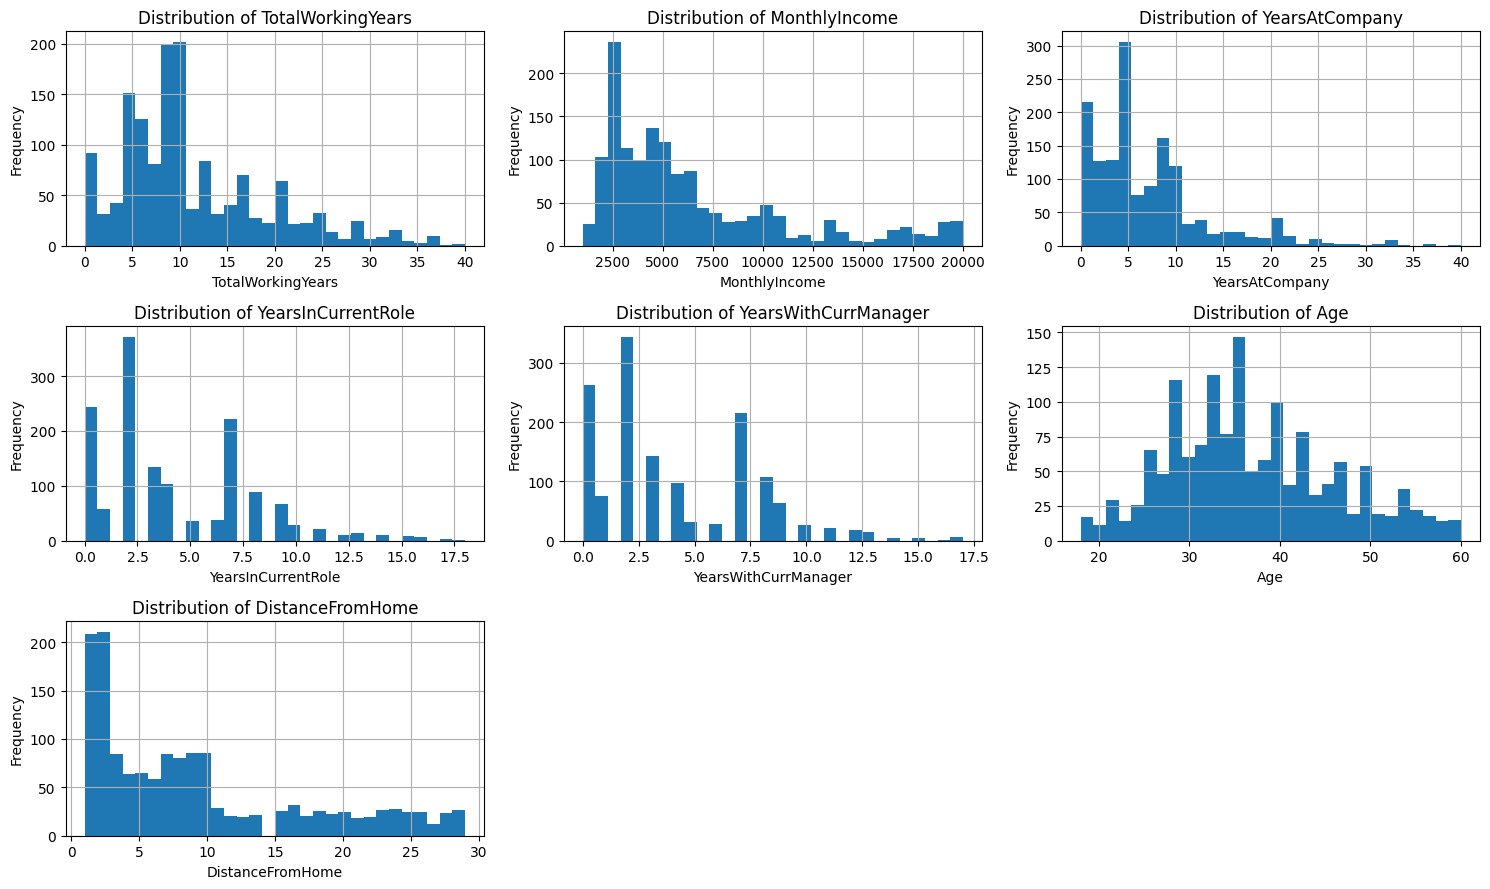

In [177]:
# Subplot to store distribution charts:
numcols = 3
num_rows = math.ceil(len(important_num)/ numcols)
plt.figure(figsize=(15, numcols * num_rows))

print("Distribution of numeric features", end="\n")
for i, col in enumerate(important_num):
  # subplot position
  plt.subplot(num_rows, numcols, i + 1)

  df[col].hist(bins=30)
  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

While the age distribution is approximately normal, the other variables are right-skewed with long right tails, pointing to the presence of outliers. If missing values were present, imputation via the median would be required during preprocessing to avoid distortion by outliers. Additionally, differing feature scales require normalization in the preprocessing pipeline.

### 4.3.3 Distribution of categoric features

Distribution of categoric features


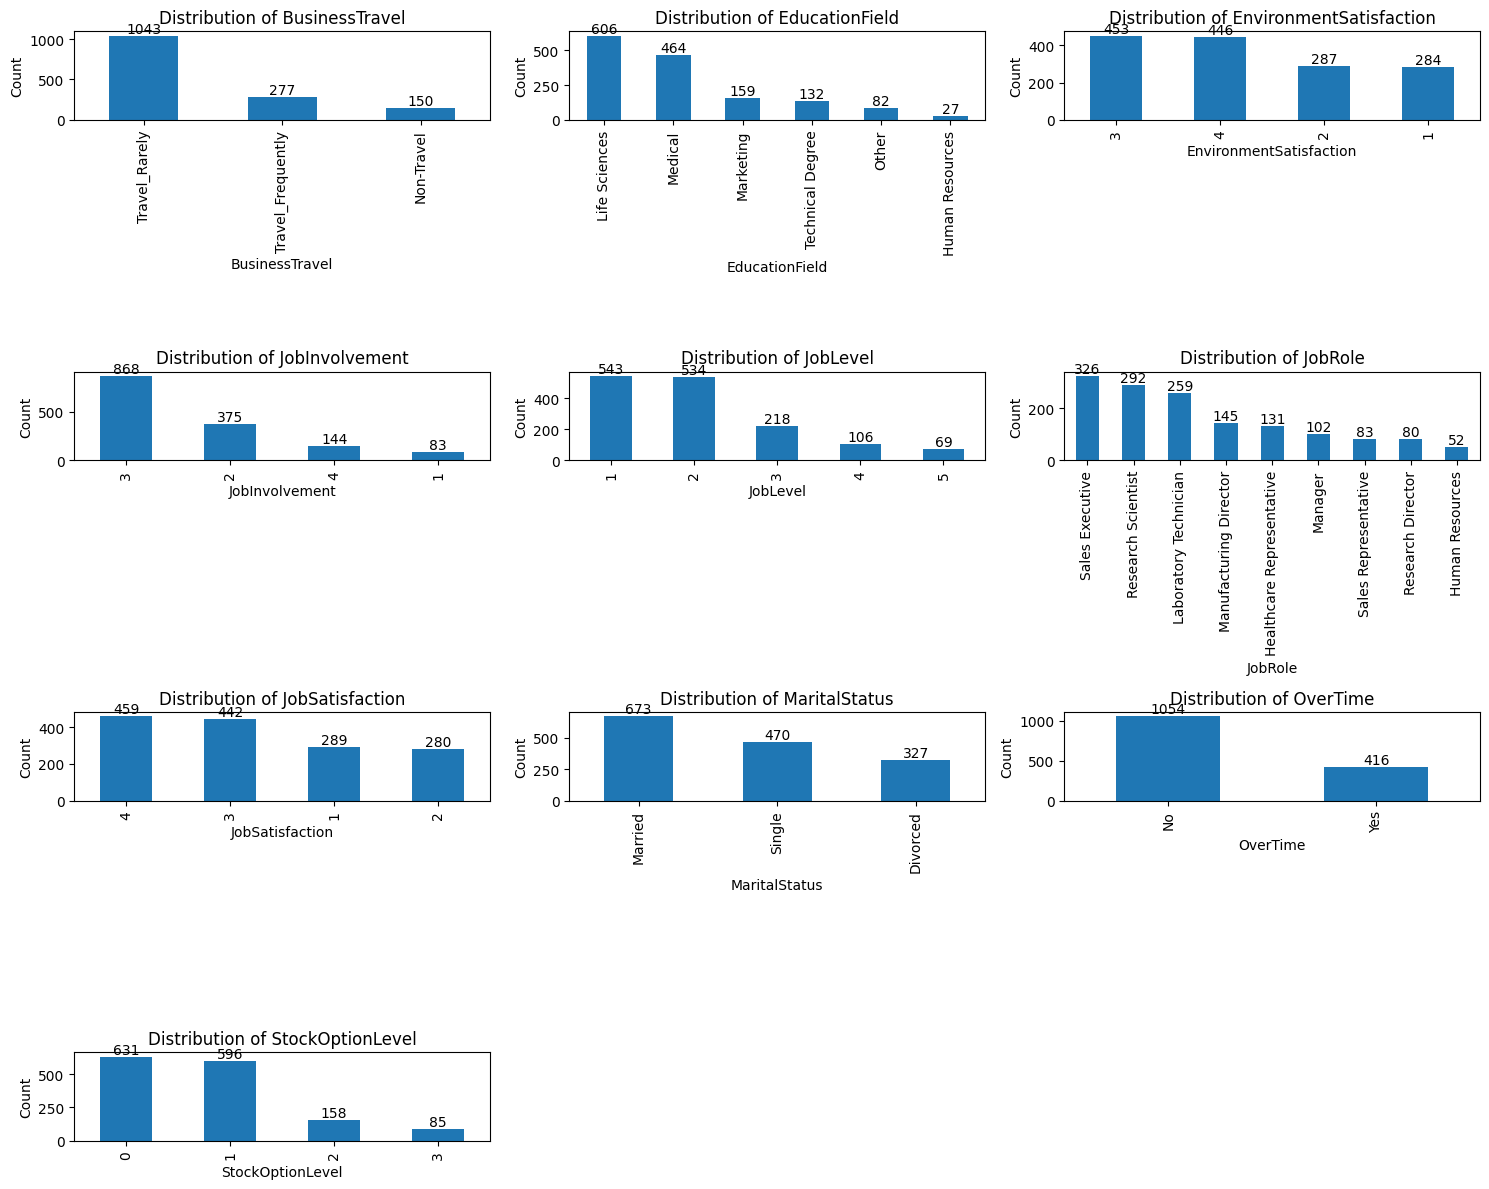

In [178]:
# Subplot to store distribution charts:
num_rows = math.ceil(len(important_cat_ord) / numcols)
plt.figure(figsize=(15, numcols * num_rows))

print("Distribution of categoric features", end="\n")
for i, col in enumerate(important_cat_ord):
  # subplot position
  plt.subplot(num_rows, numcols, i + 1)

  plot = df[col].value_counts().plot(kind="bar")
  plot.bar_label(plot.containers[0])

  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel("Count")

plt.tight_layout()
plt.show()

Several features show categories with very few examples (e.g., very low count for non-travellers in BusinessTravel in comparison to rare travellers, or only 52 samples for Human Resources in JobRole), which can reduce their predictive power.

Additionally, to bypass the need for OneHotEncoder on the OverTime feature, its "Yes"/"No" classes will be mapped directly to 1/0.

## 4.4 Summary of EDA

Based on our exploratory data analysis, the key takeaways are:
- Since no single feature exhibits a strong linear relationship with the target, we should compare models that handle linear patterns (e.g., Logistic Regression) with those capable of capturing complex relationships (e.g., XGBoost).
- The target is imbalanced (16% "Yes"), requiring stratified train-test splits and class weighting to handle the minority class properly.
- The dataset contains no missing or duplicate values, streamlining preprocessing. However, numerical features are right-skewed with potential outliers (though imputation logic is in place via the median if needed), and they operate on different scales, necessitating standardization via StandardScaler().
- Certain categorical features contain classes with very few instances (e.g., Human Resources in JobRole), which may reduce their predictive power.

# 5. Data preparation and train/test split

##5.1 Data transformation and final model setup

Before splitting the data, we converted the OverTime column from Yes/No to 1/0. This does not introduce data leakage because the transformation does not rely on any dataset-wide statistics (i.e., every "Yes" simply maps to 1, and every "No" maps to 0).

In [179]:
# Map OverTime to 1/0; safe from leakage as it's deterministic
df["OverTime"] = df["OverTime"].map({"No": 0, "Yes": 1}).astype(int)

Finally, we defined the features to be included in the model.

In [180]:
# Features definition
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]

In [181]:
# Model setup
PROBLEM_TYPE = "classification"

print("Problem type:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Number of features:", len(features))
print("Features:", features)

Problem type: classification
Target: Attrition
Number of features: 30
Features: ['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 5.2 Data splitting

The data was split into 80% training and 20% testing, with stratification to maintain the target proportion. The 80/20 split was chosen because the dataset is relatively small, ensuring we retain enough data to train the model.  

Stratifying the classes (stratify=y) is necessary, as noted in section 4.4, because the target variable is imbalanced (84% of employees stayed, and 16% left). Stratification ensures this exact proportion is preserved in both the training and test sets, avoiding the risk of ending up with a disproportionate distribution in either set.

In [182]:
X = df[features].copy()
y = df[TARGET].copy()

y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (1176, 30) | Test: (294, 30)


Note: For the initial model training, a stratified holdout approach was used due to its simplicity and lower computational cost. Cross-validation will be implemented during hyperparameter optimization to ensure the model isn't simply "memorizing" the data, which would lead to overfitting.

## 5.3 Data preparation and splitting summary

- An 80/20 split was applied to maximize the data available for training, given the small size of the dataset.
- Stratified sampling was used to preserve the imbalanced target distribution (84% stay vs. 16% leave) across both sets.
- Binary encoding of the OverTime feature was safely executed prior to the split.
- Initial baseline models utilized a stratified holdout for computational efficiency, while cross-validation was reserved for hyperparameter tuning.

# 6. Preprocessing and pipeline

## 6.1 Feature Selection

In section 3.3.6, we identified features to be dropped from the model due to their lack of predictive value. In this preprocessing step, we will check for highly multicollinear variables to remove them from the dataset. This helps reduce redundancy, improve coefficient stability, and optimize the pipeline prior to training.

To quantify multicollinearity, we will calculate the VIF (Variance Inflation Factor) (DATACAMP, 2024; PEOPLEPILOT, 2025).

In [183]:
X_train_num = X_train.select_dtypes(include=np.number)

vif = calculate_vif(X_train_num)

print(vif.to_string(float_format="{:.4f}".format))

                     feature     VIF
8                   JobLevel 10.6547
10             MonthlyIncome 10.2260
18         TotalWorkingYears  4.8854
21            YearsAtCompany  4.5896
24      YearsWithCurrManager  2.8711
22        YearsInCurrentRole  2.6049
15         PerformanceRating  2.5230
14         PercentSalaryHike  2.5197
1                        Age  2.1379
23   YearsSinceLastPromotion  1.6344
12        NumCompaniesWorked  1.2693
4                  Education  1.0612
13                  OverTime  1.0289
17          StockOptionLevel  1.0246
7             JobInvolvement  1.0243
16  RelationshipSatisfaction  1.0226
11               MonthlyRate  1.0217
6                 HourlyRate  1.0216
5    EnvironmentSatisfaction  1.0215
2                  DailyRate  1.0195
20           WorkLifeBalance  1.0190
3           DistanceFromHome  1.0171
9            JobSatisfaction  1.0167
19     TrainingTimesLastYear  1.0167


The degree of multicollinearity for some features is very high (VIF > 5 is considered high) (DATACAMP, 2024). Therefore, we need to examine the pairwise correlations between features to pinpoint the source of the issue.

In [184]:
vif_cols = vif["feature"].tolist()

corr_matrix = X_train[vif_cols].corr().abs()

# Converting the matrix into a list of pairs and sorting by the highest correlations
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ["Var_1", "Var_2", "Correlation"]

# Removing self-correlations
corr_pairs = corr_pairs[corr_pairs["Var_1"] != corr_pairs["Var_2"]]

# Displaying the top correlated feature pairs
hidden_pairs = corr_pairs.sort_values(by="Correlation", ascending=False).drop_duplicates(subset=["Correlation"])
print(hidden_pairs.head(15).to_string(float_format="{:.4f}".format))

                       Var_1                 Var_2  Correlation
1                   JobLevel         MonthlyIncome       0.9470
2                   JobLevel     TotalWorkingYears       0.7852
76            YearsAtCompany  YearsWithCurrManager       0.7764
49         TotalWorkingYears         MonthlyIncome       0.7748
151        PerformanceRating     PercentSalaryHike       0.7739
123       YearsInCurrentRole        YearsAtCompany       0.7473
101     YearsWithCurrManager    YearsInCurrentRole       0.7069
194                      Age     TotalWorkingYears       0.6945
51         TotalWorkingYears        YearsAtCompany       0.6182
219  YearsSinceLastPromotion        YearsAtCompany       0.6043
221  YearsSinceLastPromotion    YearsInCurrentRole       0.5349
72            YearsAtCompany              JobLevel       0.5267
8                   JobLevel                   Age       0.5265
32             MonthlyIncome                   Age       0.5114
73            YearsAtCompany         Mon

Examining all correlations above 70%, we observe the following:

- JobLevel is highly correlated with MonthlyIncome (95%). While MonthlyIncome is a universal metric, JobLevel can vary significantly in meaning across different companies. Furthermore, JobLevel also shows a high correlation with TotalWorkingYears (79%). Therefore, JobLevel will be dropped.

- PercentSalaryHike and PerformanceRating are also highly correlated (77%). I will drop the PerformanceRating feature, as it is a more subjective metric.

In [185]:
vif_drop = ["JobLevel", "PerformanceRating"]

After dropping the aforementioned features, all remaining variables now exhibit a VIF below 5.

In [186]:
# Remove highly correlated columns from X_train and X_test
X_train = X_train.drop(columns=vif_drop, errors="ignore")
X_test = X_test.drop(columns=vif_drop, errors="ignore")

# New VIF calculation
X_train_num = X_train.select_dtypes(include=np.number)

vif = calculate_vif(X_train_num)

print(vif.to_string(float_format="{:.4f}".format))

                     feature    VIF
16         TotalWorkingYears 4.7661
19            YearsAtCompany 4.5882
22      YearsWithCurrManager 2.8597
20        YearsInCurrentRole 2.6041
9              MonthlyIncome 2.5692
1                        Age 2.1349
21   YearsSinceLastPromotion 1.6334
11        NumCompaniesWorked 1.2680
4                  Education 1.0610
12                  OverTime 1.0289
15          StockOptionLevel 1.0222
14  RelationshipSatisfaction 1.0220
7             JobInvolvement 1.0215
5    EnvironmentSatisfaction 1.0212
10               MonthlyRate 1.0209
2                  DailyRate 1.0191
6                 HourlyRate 1.0187
18           WorkLifeBalance 1.0171
8            JobSatisfaction 1.0160
17     TrainingTimesLastYear 1.0148
3           DistanceFromHome 1.0128
13         PercentSalaryHike 1.0122


##6.2 Defining pipeline

In [187]:
# Defining numeric, ordinal e binary encoded features and set up the pipeline
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

numeric_pipe = Pipeline(steps=[
    # ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

This dataset does not contain missing values. However, if it did, median imputation would be the best strategy for numeric features, as it is robust to outliers (as noted in Section 4).

We applied StandardScaler() to bring numeric features of different scales onto a common scale, as indicated in Section 4.4.

Ordinal categorical features possess an inherent order and magnitude. Therefore, treating them the same way as nominal features (e.g., applying OneHotEncoder) would not make sense, as it would destroy their ordinal relationship. Assuming the intervals between categories (e.g., from 'Low' to 'Medium') have a linear impact on the risk, it makes more sense to group and process them alongside the numeric features.

In [188]:
# Defining nominal categoric features and set up the pipeline
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

categorical_pipe = Pipeline(steps=[
    # ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

If categorical features had missing data, I would impute them with an "Unknown" category. This avoids artificially inflating an existing class, which could introduce bias into the model. A more sophisticated approach would be KNN imputation, as it leverages values from similar neighbors; however, it is computationally more expensive and likely unnecessary for an MVP scope.

Nominal categorical features were encoded using OneHotEncoder to convert categories into binary values. The handle_unknown="ignore" parameter was applied to prevent errors in case the test set contains unseen categories not present in the training data.

In [189]:
# Class ratio for XGBoost to penalize minority class errors
scale_xgboost = (y_train == 0).sum() / (y_train == 1).sum()

Unlike other scikit-learn models, XGBoost does not support the class_weight="balanced" parameter. To address class imbalance, we manually calculated the scale_pos_weight, which represents the ratio of the majority class ("No") to the minority class ("Yes"). This instructs XGBoost to assign a higher weight to minority class instances during training.

In [190]:
preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


## 6.3 Preprocessing Summary

- Dropped JobLevel and PerformanceRating based on VIF analysis to eliminate multicollinearity.

- As there are no missing values in the dataset, the strategy — Median for numeric and "Unknown" for categorical — was kept commented in the code as a best practice.

- Applied StandardScaler to standardize numeric features.

- Applied OneHotEncoder to nominal features. Ordinal features were grouped with numeric data to preserve their inherent ordering.

- Manually calculated scale_pos_weight for XGBoost to heavily penalize minority class misclassifications.

Note: Intuitively, features like HourlyRate, DailyRate, and MonthlyRate seemed like strong candidates for removal, assuming a high correlation with MonthlyIncome. However, likely because this is a synthetic dataset, these correlations were surprisingly weak. Therefore, they were kept in the final dataset.




# 7. Baseline and candidate models

### 7.1 Models Justification

The baseline is the DummyClassifier, using the "stratified" strategy. This means the model predicts randomly while respecting the target proportion (84% "No" / 16% "Yes"). By chance, the model is expected to correctly guess 16% of the minority class, resulting in a recall of around 16%. This will make it possible to analyze if other models are capable of learning something and identifying the minority class more frequently.

The candidate models represent different approaches. They are:

* **Logistic Regression (LR):** This model works well with linear relationships. Although item 4.2 did not present variables with high correlation to the target, it will be interesting to explore the final results. This model is simple and interpretable, and it would be easy to identify variables that have more weight in the model.
* **Extreme Gradient Boosting (XGBoost):** This model works with decision trees sequentially, so that one tree corrects the errors of the previous one. Additionally, it captures interactions between features — for example, the combination of overtime and time without promotion might have a greater impact than each factor in isolation. Unlike LightGBM and Random Forest, which were models considered as candidates, this one has regularizations that penalize overly complex trees, which helps to avoid overfitting.
* **Support Vector Machine (SVM):** It is a good model for this dataset because it prioritizes the geometric simplicity of the model, instead of trying to fit every single data point, resisting overfitting. Unlike tree-based models, SVM uses a different approach, creating a hyperplane to separate the classes, which makes comparing them interesting. The "rbf" kernel (default) was kept so we can explore any non-linear relationship (although a linear kernel could be an alternative given that linear models might work well for this problem). We also added `probability=True`, because ROC-AUC needs probabilities to be calculated, instead of predicted classes.

With the differences between them, we will be able to evaluate which type of approach is most suitable for this problem.

In [191]:
baseline = Pipeline(steps=[
  ("preprocess", preprocess),
  ("model", DummyClassifier(strategy="stratified", random_state=SEED))
])

candidates = {
  "LogisticRegression": Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=500, random_state=SEED, class_weight="balanced"))
  ]),
  "XGBoost": Pipeline(steps=[
      ("preprocess", preprocess),
      ("model", XGBClassifier(random_state=SEED, scale_pos_weight=scale_xgboost))
  ]),
  "SVM": Pipeline(steps=[
      ("preprocess", preprocess),
      ("model", SVC(random_state=SEED, probability=True, class_weight="balanced"))
  ])
}

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'XGBoost', 'SVM']


**Notes:**
- SVM and LR are sensitive to scale, which justifies the `StandardScaler()` treatment (item 6).
- To better handle imbalanced data and give more weight to the minority class, `class_weight="balanced"` was defined for most models and `scale_pos_weight=scale_xgboost` for XGBoost. `scale_xgboost` was also defined in preprocessing (item 6).
- SVM with rbf kernel (default) does not have direct interpretability like linear models — it would be necessary to use SHAP if this were the chosen model, or permutation importance.

# 8. Training and Initial Evaluation

In [192]:
results = {}
trained_models = {}

# Baseline
model = compute_models("baseline", baseline, X_train, y_train, X_test, y_test, results)
trained_models["baseline"] = model

# Modelos candidatos
for name, model in candidates.items():
  model = compute_models(name, model, X_train, y_train, X_test, y_test, results, True)
  trained_models[name] = model

print("\nTest results:")
print("\n*recall_train for under/overfitting analysis")

show_results_table(results)



Test results:

*recall_train for under/overfitting analysis


,recall,f1,roc_auc,train_time_s,*recall_train
baseline,0.1277,0.1250,0.4768,0.024,NaN
LogisticRegression,0.6809,0.4885,0.8117,0.161,0.8000
XGBoost,0.2766,0.3714,0.7743,0.411,1.0000
SVM,0.6383,0.5505,0.8111,0.750,0.9526


## 8.1 Initial Results Analysis

All models suffer from overfitting to a greater or lesser degree. Notice that the training recall for Logistic Regression is approximately 80%, while on the test set it is around 68%, indicating mild overfitting. Overfitting is much more severe in SVM (95% train vs. 64% test) and extremely strong in XGBoost (100% training recall, paired with a very low test recall). The baseline's overfitting was not analyzed because it is irrelevant here; by definition, the `DummyClassifier` does not learn any patterns from the data.

### Looking at test performance individually:
- **Dummy Classifier:** Achieved a recall of 12.8% and a low ROC-AUC (47.7%) due to its difficulty in effectively separating the classes. This model learns nothing and serves strictly as a reference point.
- **Logistic Regression (LR):** Presented the best recall at 68.1% (approximately 2% below target) and an ROC-AUC of 81.2% (above target). It also had the best training time among the candidate models.
- **SVM:** Achieved the second-best recall (63.8%) and a solid ROC-AUC (81.1%). Its F1-score was higher than that of LR.
- **XGBoost:** Yielded a better recall than the baseline (27.7%), but still well below an acceptable result. Its ROC-AUC was 77.4%.

==================================================

**If recall is low in XGBoost, why is ROC-AUC high?**
> ROC-AUC indicates whether the model was able to separate the classes by assigning a higher probability to the positive instance. Recall indicates whether the model correctly identified a class, considering a threshold (default = 50%). When the probability stays above the threshold, the model would indicate attrition. ROC-AUC was effective in assigning significantly different probabilities for the classes (very close to the target), but this does not mean the attrition probability surpassed the threshold. For example, a 10% probability for "No" versus 40% for "Yes" (below the threshold) would still result in the model classifying it as "No" (low recall), despite there being a large difference in probability between "Yes" and "No" (resulting in a high ROC-AUC).

==================================================

Considering the low correlation between the features and the target, I was surprised that LR achieved a better result. A plausible explanation is that more complex models suffered more from overfitting on the small dataset (as evidenced by the 100% training recall for XGBoost and 95% for SVM, compared to much lower test results). Logistic Regression, being simpler, generalized better to the test set, showing a smaller gap between training (80%) and testing (68%).

The training time for all models was acceptable.

# 9. Hyperparameter Tuning and Optimization


##9.1 Hyperparameter Search Space

The metric we are aiming to improve is **recall**.

For LR, the model will search for the optimal *C* value using L1 regularization (Lasso). The reason for using Lasso is to try and minimize the number of features that carry weight in the model, helping to reduce overfitting. This acts as an extra safeguard, since VIF has already helped eliminate columns with high collinearity during preprocessing. The *C* parameter is the inverse of regularization strength (*C* = 1/λ); therefore, values closer to zero increase the model's regularization.

For XGBoost, I am allowing the model to search for the ideal number of trees (`n_estimators`) and maximum depth (`max_depth`) to minimize complexity. The learning rate determines the weight of each tree in the model and the speed at which the boosting algorithm learns at each iteration. A smaller learning rate decreases the weight of each tree, slowing down the learning process and preventing overfitting.

Finally, for the SVM, the search parameter is *gamma* (γ), which controls how fast the similarity between two data points drops as the distance between them increases. A small gamma allows distant data points to have a significant influence on one another, making the "decision boundary" smoother and leaving the model less prone to overfitting (IBM and GEEKS FOR GEEKS, 2024).

In [193]:
scoring = "recall"

param_dist = {
    "LogisticRegression": {
      "model__C": loguniform(0.01, 100),
      "model__penalty": ["l1"], #elasticnet
      # "model__l1_ratio": uniform(0, 1),
      "model__solver": ["saga"]
    },
    "XGBoost": {
      "model__n_estimators": randint(50, 250),
      "model__max_depth": randint(2, 20),
      "model__learning_rate": uniform(0.05, 0.15)
    },
    "SVM": {
      "model__gamma": loguniform(0.001, 1)
      # "model__kernel": ["linear", "rbf"],
      # "model__C": loguniform(0.01, 10) # testado mas piorou os resultados
    }
}

##9.2 Hyperparameter Optimization

Below, we search for the best hyperparameters to optimize recall using cross-validation (`StratifiedKFold` with 5 folds and 15 random iterations per model). Stratification ensures that the 84%/16% target class proportion is maintained across every fold during the search.

In [194]:
results_opt = {}
estimators = {}

N_ITER_SEARCH = 15
search = None

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, model in candidates.items():
  search = RandomizedSearchCV(
      model,
      param_distributions=param_dist[name],
      n_iter=N_ITER_SEARCH,
      cv=cv,
      scoring=scoring,
      random_state=SEED,
      n_jobs=1,  # use 1 to avoid instability in some exec environments
      verbose=1
  )

  search = compute_models(name, search, X_train, y_train, X_test, y_test, results_opt, True)
  estimators[name] = search.best_estimator_

  print("Model name:", name)
  print("Best validation score:", search.best_score_)
  print("Best hyperparameters:", search.best_params_)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Model name: LogisticRegression
Best validation score: 0.7526315789473685
Best hyperparameters: {'model__C': np.float64(0.053370327626039576), 'model__penalty': 'l1', 'model__solver': 'saga'}
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Model name: XGBoost
Best validation score: 0.6263157894736842
Best hyperparameters: {'model__learning_rate': np.float64(0.07727374508106509), 'model__max_depth': 2, 'model__n_estimators': 107}
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Model name: SVM
Best validation score: 0.7526315789473684
Best hyperparameters: {'model__gamma': np.float64(0.0014936568554617625)}


## 9.3 Comparison of results before and after optimization

In [195]:
# @title Execute Hidden Code

metrics = ["recall", "f1",	"roc_auc", "train_time_s", "*recall_train"]

for metric in metrics:
  print("==================", metric, "=================")
  table = []

  for name, result in results.items():
    if name != "baseline":
      table.append({
        'Model': name,
        'Before': results[name][metric],
        'After': results_opt[name][metric],
        'Diff': results_opt[name][metric] - results[name][metric]
      })

  print(pd.DataFrame(table))
  print("")
print("*recall_train for under/overfitting analysis")



================== recall =================
                Model  Before   After    Diff
0  LogisticRegression  0.6809  0.6809  0.0000
1             XGBoost  0.2766  0.6596  0.3830
2                 SVM  0.6383  0.7021  0.0638

================== f1 =================
                Model  Before   After    Diff
0  LogisticRegression  0.4885  0.4604 -0.0281
1             XGBoost  0.3714  0.4960  0.1246
2                 SVM  0.5505  0.4889 -0.0616

================== roc_auc =================
                Model  Before   After    Diff
0  LogisticRegression  0.8117  0.8032 -0.0085
1             XGBoost  0.7743  0.7948  0.0205
2                 SVM  0.8111  0.8109 -0.0002

================== train_time_s =================
                Model  Before   After    Diff
0  LogisticRegression   0.161  46.870  46.709
1             XGBoost   0.411  20.152  19.741
2                 SVM   0.750  23.921  23.171

================== *recall_train =================
                Model  Before 

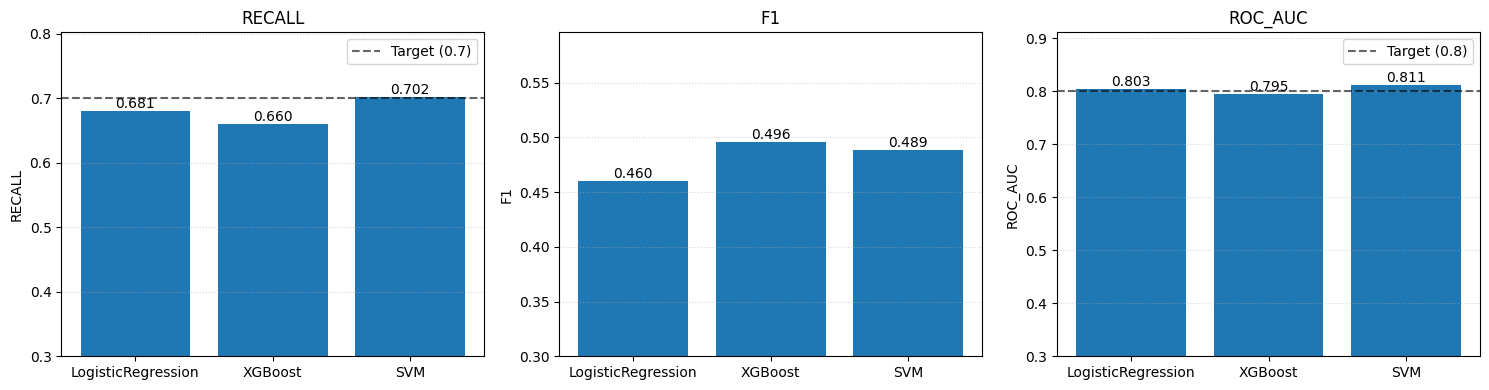

In [196]:
# @title Execute Hidden Code
# Simplified Chart: Recall and F1-score for optimized models
model_names = ["LogisticRegression", "XGBoost", "SVM"]
metrics = ["recall", "f1",	"roc_auc"]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

for i, metric in enumerate(metrics):
  ax = axes[i]
  res = []

  for m in model_names:
    res.append(results_opt[m][metric])

  bars = ax.bar(model_names, res)

  # Configura o target e o limite do eixo Y de forma limpa
  if metric in ["recall", "roc_auc"]:
    t = 0.70 if metric == "recall" else 0.80
    ax.axhline(t, color="black", linestyle="--", alpha=0.6, label=f"Target ({t})")
    ax.legend(loc="upper right", frameon=True)


  ax.bar_label(bars, fmt="%.3f")

  ax.set_ylabel(metric.upper())
  ax.set_title(metric.upper())
  ax.set_ylim(0.3, max(res) + 0.1)
  ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


## 9.4 Discussion of Optimization Results

- The number of search iterations (`N_ITER_SEARCH`) was tested across values of 5, 10, 15, 20, and 30. The ideal number was 15 (with no changes observed for `N_ITER_SEARCH` > 15).
- For LR, the chosen hyperparameter (*C* = 0.053) makes sense, as high regularization is required to reduce feature weights. However, there was no change in recall, and there was a drop in both F1-score (from 48.9% to 46.0%) and ROC-AUC (from 81.2% to 80.3%). What we observe, however, is a slight reduction in overfitting (the gap between training and testing recall dropped from 12 percentage points to approximately 10 percentage points after optimization), meaning that despite the drop in some metrics, the model generalizes slightly better. Testing the default penalty (L2) or ElasticNet (a mix of L1 and L2 regularization) did not alter the results. This suggests that removing features beforehand via VIF already helped simplify the model's dimensionality, and that LR has reached the limit of its predictive power on this dataset.
- For XGBoost, the hyperparameter search yielded a learning rate of 7.7%, meaning each tree has a low contribution; tree depth settled at 2 and the number of estimators at 107 to reduce model complexity. This greatly reduced overfitting while also bringing a significant improvement in recall (from 27.7% to 66.0%). Its F1-score was the highest among all optimized models (increasing from 37.1% to 49.6%). ROC-AUC also improved by approximately 2 percentage points (from 77.4% to 79.5%).
- In the SVM, *gamma* = 0.001 had a positive effect on recall (rising from 63.8% to 70.2%), but worsened the F1-score (from 55.0% to 48.9%). This can be justified by the trade-off between higher recall and lower precision—the model now reduces the number of false negatives, but at the expense of an increase in false positives. There were no significant changes in ROC-AUC (81.1%). When analyzing overfitting, however, there was a massive improvement: it became the model with the smallest gap between training and testing recall (dropping from a 31.5 percentage point difference down to just a 7.7 percentage point difference). For documentation purposes, I also tested tuning the SVM's penalty parameter (*C*), which distorted the model and caused it to classify almost every instance as "Yes" (recall: 100%, F1: 27.6%, ROC-AUC: 32.8%). For this reason, I only allowed the adjustment of the gamma parameter, as seen in section 9.1.

Thus, the model that achieved the recall target (with 70.2%) was the **SVM**. LR came in second place, with a recall of 68.1%. The ROC-AUC for both of these models remained above the target, with the SVM's score being approximately 1 percentage point higher than that of LR.

Despite having the lowest recall among the three models, XGBoost showed a significant improvement after selecting a low learning rate and low tree depth. It would be interesting to explore a larger-scale dataset, as a small dataset may have limited this model's ability to identify non-linear patterns. With more time, it would also be interesting to build an ensemble of these models to see if there would be significant further improvements.

# 10. Final Evaluation on the Test Set


## 10.1 Model with the highest recall (70%): SVM

Final model: SVM
Recall (Train) - for under/overfitting analysis: 0.7789 

              precision    recall  f1-score   support

           0       0.93      0.78      0.85       247
           1       0.38      0.70      0.49        47

    accuracy                           0.77       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.77      0.79       294



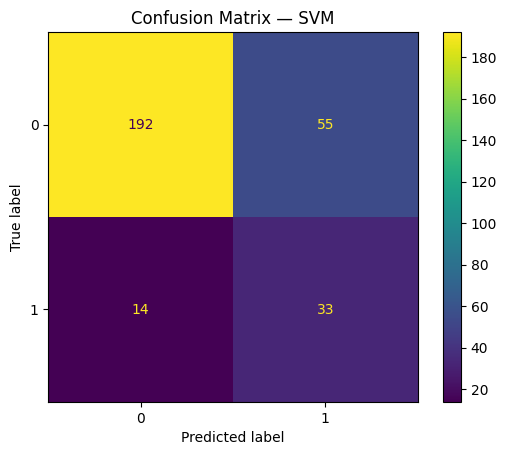

In [197]:
final_model_name = "SVM"
final_model = estimators[final_model_name]

print("Final model:", final_model_name)

print("Recall (Train) - for under/overfitting analysis:", round(results_opt[final_model_name]["*recall_train"], 4), "\n")

y_pred_test = final_model.predict(X_test)

print(classification_report(y_test, y_pred_test))
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
plt.title("Confusion Matrix — SVM")
plt.show()


## 10.2 Highest Weighted Features in the SVM

One of the methods we could use to identify the highest weighted features in the model is SHAP. It is considered a highly interpretability-focused method for non-linear kernels; however, it has a "high computational cost" (testing it in this MVP, its execution took almost 17 minutes, which exceeded the time and agility required for the scope of an MVP).

Therefore, we will use permutation importance to capture the most important features. Unlike SHAP, which assigns feature weights within the model, permutation importance measures how much the random shuffling of a feature negatively impacts the main metric. The features that cause the largest "drop" in the recall metric can be considered the most important ones. It should be noted, however, that permutation importance may fail to capture the importance of all features when using a small dataset (GEEKS FOR GEEKS, 2025 and DATACAMP).


In [198]:
# Increased n_repeats from 5 to 15 to ensure more reliable results on a small dataset
perm_imp = permutation_importance(
    final_model, X_test, y_test, random_state=SEED, n_jobs=-1, scoring=scoring, n_repeats=15
)

feature_names = X_test.columns

df_perm = pd.DataFrame({
    "feature": feature_names,
    "drop_on_recall": perm_imp.importances_mean
})

df_perm = df_perm.sort_values("drop_on_recall", ascending=False)

print("=== KEY FEATURES FOR RETENTION ===")
print(df_perm[df_perm["drop_on_recall"] > 0].to_string(float_format="{:.4f}".format))

=== KEY FEATURES FOR RETENTION ===
                     feature  drop_on_recall
17                  OverTime          0.1362
21         TotalWorkingYears          0.0426
24            YearsAtCompany          0.0326
0                        Age          0.0312
19  RelationshipSatisfaction          0.0312
13             MaritalStatus          0.0298
14             MonthlyIncome          0.0284
4           DistanceFromHome          0.0213
25        YearsInCurrentRole          0.0199
16        NumCompaniesWorked          0.0199
22     TrainingTimesLastYear          0.0199
2                  DailyRate          0.0184
26   YearsSinceLastPromotion          0.0170
1             BusinessTravel          0.0156
9                 HourlyRate          0.0142
20          StockOptionLevel          0.0142
12           JobSatisfaction          0.0099
27      YearsWithCurrManager          0.0099
8                     Gender          0.0071
18         PercentSalaryHike          0.0057


## 10.3 Error Analysis and Limitations

Since the goal was to minimize the number of false negatives, **recall** was chosen as the target metric. However, achieving a strong result comes at the expense of precision, which was not as high.

The SVM was the best-performing model in terms of recall (70.2% — reaching our target). Compared to the baseline (recall = 12.8%), the model was able to learn and identify the minority class much more effectively.

### Confusion Matrix and Trade-offs
The confusion matrix showed 33 true positives, 14 false negatives, and 55 false positives. While the objective of keeping false negatives low was relatively achieved, it came at the cost of lower precision (38%), resulting in a high number of false positives (55). This is a concern because, as mentioned earlier, the company would spend resources trying to retain employees who had no intention of leaving. **Threshold tuning** could be an option to reduce the number of false positives, but it would drop recall below our target, which is not the intention of this project.

We also noticed slight overfitting (77.9% training recall vs. 70.2% test recall), likely as a consequence of using a small dataset.

### Interpretability Challenges
Another limitation is model interpretability. While Permutation Importance is computationally faster than SHAP (as detailed in section 10.2), it lacks directionality. To understand whether a feature impacts attrition positively or negatively, we must rely on the target correlation from section 4.2. Although standard best practice is to calculate correlation after data splitting, we refer back to those initial values to simplify this analysis.

Despite these limitations, the SVM was the best model due to superior generalization and stronger overall metrics. While not perfect, it can serve as a practical guide for attrition management. For a real-world deployment, HR recommendations include:
* Developing company-wide retention policies based on the model's key drivers.
* Assessing individual attrition risk specifically for high-priority retention targets, such as employees internally designated as *top talents* or *high potentials*.

---

## Key Drivers and Initial Hypotheses

Using permutation importance to identify the features causing the largest "drop in recall," alongside target correlation to understand positive/negative impact (section 4.2), the top 3 features are:

* **OverTime (0.136):** Shows that employees working overtime have a significantly higher risk of leaving — within Attrition = "Yes", employees who worked overtime had a 30% rate compared to 10% for those who did not. Implicitly, OverTime impacts WorkLifeBalance (initial hypothesis), so we expected this variable to influence the model in a similar proportion. However, WorkLifeBalance did not appear among the top features.
* **TotalWorkingYears (0.043) and YearsAtCompany (0.033):** Show that shorter total work experience and fewer tenure years at the company increase attrition risk (negative correlation). Interestingly, our initial hypothesis assumed that YearsSinceLastPromotion (0.017) would be a more important variable; however, this was not confirmed by the data.
* **EnvironmentSatisfaction:** Another variable strongly considered in our initial hypothesis, it did not appear in the results table above at all. As mentioned in section 10.2, this failure to capture its significance could be the result of working with a small dataset.



# 11. Final Model Comparison

Below is the comparison table, sorted in descending order by recall, F1-score, and ROC-AUC, respectively. The optimized SVM was selected for achieving the highest recall (70.2%) and a ROC-AUC above the target.




In [199]:
table = [list_add("DummyClassifier (baseline)", results, "baseline", "N/A")]

for name, result in results.items():
  if name != "baseline":
    table.append(list_add(name + " (initial)", results, name, "N/A"))

for name, result in results_opt.items():
  comment = "N/A"
  if name == "SVM":
    comment = "Chosen model"
  table.append(list_add(name + " (optimized)", results_opt, name, comment))

table = pd.DataFrame(table)
table = table.sort_values(by=["Recall", "F1", "ROC-AUC"], ascending=[False, False, False])
print(table.reset_index(drop=True).to_markdown(tablefmt="grid"))

+----+--------------------------------+----------+--------+-----------+--------------+--------------+
|    | Model                          |   Recall |     F1 |   ROC-AUC |   Train Time | Comments     |
+====+================================+==========+========+===========+==============+==============+
|  0 | SVM (optimized)                |   0.7021 | 0.4889 |    0.8109 |       23.921 | Chosen model |
+----+--------------------------------+----------+--------+-----------+--------------+--------------+
|  1 | LogisticRegression (initial)   |   0.6809 | 0.4885 |    0.8117 |        0.161 | N/A          |
+----+--------------------------------+----------+--------+-----------+--------------+--------------+
|  2 | LogisticRegression (optimized) |   0.6809 | 0.4604 |    0.8032 |       46.87  | N/A          |
+----+--------------------------------+----------+--------+-----------+--------------+--------------+
|  3 | XGBoost (optimized)            |   0.6596 | 0.496  |    0.7948 |       20.1

# 12. Best Practices and Traceability

**Decision Log**

| Decision | Rationale | Expected Impact |
|---|---|---|
| Seed = 42 | Ensure reproducibility across runs. | Anyone can replicate the exact same results. |
| Recall as primary metric | Imbalanced target — minimizing false negatives is more critical than avoiding false positives. | Focus on correctly identifying the minority class. |
| Convert OverTime from Yes/No to 0/1 | Binary feature that does not require One-Hot Encoding. | Reduces dimensionality while preserving interpretability. |
| Stratified splitting (`stratify=y`) | Maintain the imbalanced target proportion (84%/16%) across train and test sets. | Prevents data splits with class distributions that differ from the original dataset. |
| `class_weight="balanced"` and `scale_pos_weight` | Models must assign higher penalties to minority class misclassifications. | Improves recall for the minority class. |
| `DummyClassifier` baseline using `stratified` strategy (instead of `most_frequent`) | Establish a performance floor while ensuring at least some minority class predictions. | Confirms that evaluated models learned real predictive patterns. |
| LR as candidate model | Capture linear relationships between features and the target. | Compares linear performance against complex models; provides interpretability via coefficients. |
| XGBoost as candidate model | Capture non-linear relationships efficiently. | Improves recall over baseline by identifying complex patterns. |
| SVM as candidate model | Capture non-linearities while aiming to prevent overfitting. | Improves recall through a geometric approach distinct from tree-based models. |
| Keep default SVM kernel (`rbf`) | Capture non-linear relationships. | Generates a more flexible decision boundary. |
| Remove constant columns (`EmployeeCount`, `Over18`, `StandardHours`) | Zero predictive value (zero variance). | Reduces dimensionality without losing information. |
| Remove `EmployeeNumber` | Unique identifier with no predictive power. | Prevents data leakage and noise. |
| Remove highly collinear columns (`JobLevel` and `PerformanceRating`) | `JobLevel` shows 95% correlation with `MonthlyIncome`; `PerformanceRating` shows 77% correlation with `PercentSalaryHike`. | Reduces dimensionality, relying on the retained proxy features to explain variance. |
| Keep ordinal variables as numeric | Preserve natural order (e.g., 1 < 2 < 3 < 4). | Better captures the ordinal relationship with the target. |
| `StandardScaler` application | Numeric features have vastly different scales (e.g., `MonthlyIncome`). | Prevents features with larger magnitudes from dominating the decision boundary. |
| One-Hot Encoding (`OneHotEncoder`) | Nominal categorical features lack natural ordering. | Enables models to interpret categorical data correctly without assuming false hierarchy. |
| L1 regularization (Lasso) in LR | Shrink weights of irrelevant features to zero. | Simplifies the model and reduces overfitting. |
| `RandomizedSearchCV` with `n_iter=15` | Limited computational time and resources. | Efficient search without exhaustive cost (`n_iter > 15` yielded no performance gains). |
| Holdout validation for initial testing | Simplicity and lower computational cost. | Fast evaluation of baseline models prior to optimization. |
| `StratifiedKFold` (5 folds) for optimization | Small dataset — requires a more robust performance estimate. | Compensates for holdout limitations on small data sizes. |
| Permutation Importance over SHAP for SVM interpretability | High computational cost of running SHAP on SVM. | Captures high-impact features with much greater computational efficiency. |

# 13. Conclusion

The main objective of this work was to predict employee attrition risk and identify the key features driving this behavior.

As established in our methodology, we prioritized **recall** (target = 70%) to minimize false negatives and retain talent, while maintaining a baseline ROC-AUC above 80% for class separation.

In this context, the best-performing model was  **SVM** (optimized), which achieved 70.2% recall, 48.9% F1-score, and 81.1% ROC-AUC. However, as analyzed in previous sections, we encountered some practical challenges:
* **Precision-Recall Trade-off:** Increasing recall caused a high number of false positives, which lowered precision (38%) and limited the F1-score across all models.
* **Dataset and Interpretability Limits:** The small, synthetic nature of the dataset likely caused the slight overfitting observed and limited the capacity of permutation importance to capture all feature weights (as discussed in sections 10.2 and 10.3).

Despite these limitations, the SVM exhibited the lowest overfitting and strongest overall generalization, making it a valuable guide for HR attrition analysis.

Regarding our initial hypotheses, `EnvironmentSatisfaction`, `WorkLifeBalance`, and `YearsSinceLastPromotion` were refuted as top predictors. Instead, `OverTime` emerged as one of the most critical drivers. Intuitively, overtime should impact work-life balance, but that relationship was not confirmed - a limitation that could be addressed in an enterprise environment using a larger dataset and SHAP for deeper interpretability.

Given more time, next steps would include:
* Combining the top models in an **ensemble** approach to evaluate potential improvements in metrics and overfitting reduction.
* Investigating oversampling techniques like **SMOTE** as an alternative to `class_weight` / `scale_pos_weight`.
* Testing the pipeline on a larger, real-world dataset to validate model stability.














# 14. Sources


In addition to lecture materials and official Python library documentation, the following sources were also consulted:
1. DATACAMP. **Variance Inflation Factor (VIF): How to Deal with Multicollinearity in Regression Analysis**. [s.l.], 2024. Available at: https://www.datacamp.com/tutorial/variance-inflation-factor. Accessed: June 20, 2026.
2. DATACAMP. **Permutation Importance**. [s.l.], [2026?]. Available at: https://campus.datacamp.com/courses/explainable-ai-in-python/model-agnostic-explainability?ex=1. Accessed: July 2, 2026.
3. DATACAMP. **SHAP Explainability**. [s.l.], [2026?]. Available at: https://campus.datacamp.com/courses/explainable-ai-in-python/model-agnostic-explainability?ex=4. Accessed: July 2, 2026.
4. GEEKS FOR GEEKS. **Determining Feature Importance in SVM Classifiers with Scikit-Learn**. [s.l.], 2025. Available at: https://www.geeksforgeeks.org/machine-learning/determining-feature-importance-in-svm-classifiers-with-scikit-learn/#choosing-the-right-method. Accessed: July 2, 2026.
5. GEEKS FOR GEEKS. **Gamma Parameter in SVM**. [s.l.], 2025. Available at: https://www.geeksforgeeks.org/machine-learning/gamma-parameter-in-svm. Accessed: June 20, 2026.
6. GEEKS FOR GEEKS. **Machine Learning Explainability using Permutation Importance**. [s.l.], 2025. Available at: https://www.geeksforgeeks.org/machine-learning/machine-learning-explainability-using-permutation-importance. Accessed: July 3, 2026.
7. IBM. **What is XGBoost?**. [s.l.], [2026?]. Available at: https://www.ibm.com/think/topics/xgboost. Accessed: June 20, 2026.
8. MID BY FALCONI. **Talent Retention: The Invisible Challenge for Mid-Sized Companies**. [s.l.], 2026. Available at: https://midfalconi.com/artigo/retencao-de-talentos-medias-empresas. Accessed: June 13, 2026. (in Portuguese).
9. PEOPLEPILOT. **Logistic Regression for Building an Attrition Risk Model: A Practical HR Guide**. [s.l.], 2025. Available at: https://www.peoplepilot.io/blog/logistic-regression-for-building-an-attrition-risk-model. Accessed: June 13, 2026.
10. SURVEYLAB. **What is Nominal Data and How to Use It?**. [s.l.], 2024. Available at: https://www.surveylab.com/blog/what-is-nominal-data. Accessed: July 1, 2026.

  
<br>

In addition to the sources mentioned above, I would like to declare the use of AI tools, specifically Claude (Anthropic) and/or Gemini (Google), during the following stages of this project:
* Suggesting code snippets and/or debugging sections related to analyzing the relationship between variables and the target, as well as the permutation importance implementation;
* Proofreading for grammar, consistency, and overall text coherence.

The project scope, objectives, definition of key metrics, choice of models, analytical discussions, and final conclusions are my own work.